In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("movie_dataset.csv")
df.head()

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


Создаем бинарную целевую переменную - успешность фильма

In [17]:
median_revenue = df['revenue'].median()
df['success'] = (df['revenue'] > median_revenue + 15000000).astype(int)

print(f"Медианный доход: ${median_revenue:,.2f}")

Медианный доход: $19,170,001.00


Анализ целевой переменной

In [18]:
(unique, counts) = np.unique(df['success'], return_counts=True)
print('Unique values of the target variable: ', unique)
print('Counts of the target variable:', counts)

Unique values of the target variable:  [0 1]
Counts of the target variable: [2788 2015]


Построим столбчатую диаграмму, чтобы увидеть целевую переменную:

<Axes: xlabel='success', ylabel='count'>

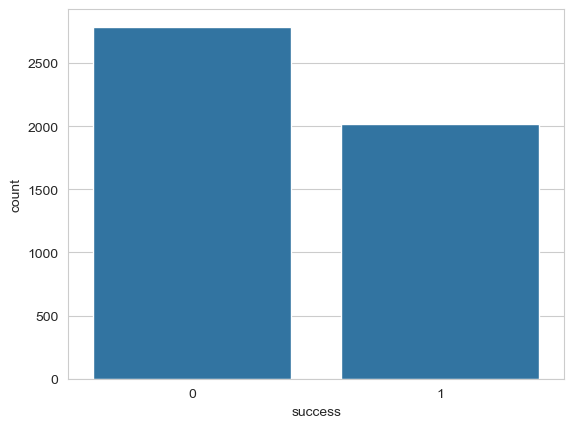

In [19]:
sns.set_style("whitegrid")
sns.countplot(df, x = 'success')

Анализ диаграммы показывает, что набор данных является сбалансированным

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   object 
 3   homepage              1712 non-null   object 
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   object 
 6   original_language     4803 non-null   object 
 7   original_title        4803 non-null   object 
 8   overview              4800 non-null   object 
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   object 
 11  production_countries  4803 non-null   object 
 12  release_date          4802 non-null   object 
 13  revenue               4803 non-null   int64  
 14  runtime               4801 non-null   float64
 15  spoken_languages     

В этом наборе данных у нас есть два класса: 0 и 1, что делает эту задачу задачей бинарной классификации

Выполним бинарную классификацию с использованием логистической регрессии с помощью sklearn
####  Проверяем наличие пропущенных значений

In [21]:
# Проверяем на пропущенные значения
print(df.isnull().sum())

index                      0
budget                     0
genres                    28
homepage                3091
id                         0
keywords                 412
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                      43
crew                       0
director                  30
success                    0
dtype: int64


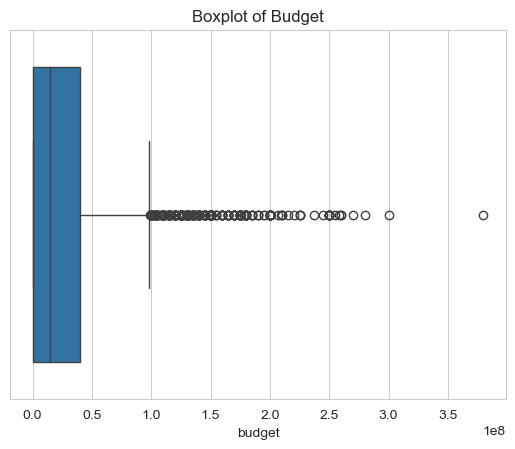

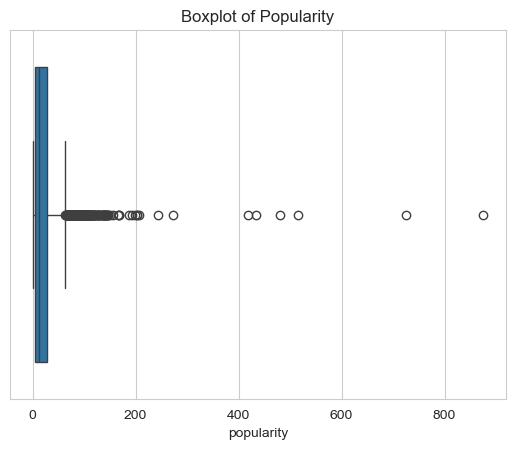

In [25]:
# проверяем на выбросы
sns.boxplot(x=df['budget'])
plt.title('Boxplot of Budget')
plt.show()
sns.boxplot(x=df['popularity'])
plt.title('Boxplot of Popularity')
plt.show()

#### Исключаем невлияющие категориальные признаки

In [69]:
df_copy = df.copy()
cat_feat = ['index', 'id', 'homepage', 'original_language', 'original_title', 'overview', 'tagline', 'title', 'release_date', 'keywords', 'production_companies', 'production_countries', 'spoken_languages', 'cast', 'crew']
df_copy.drop(cat_feat, axis = 1, inplace = True)
df_copy.head()

,budget,genres,popularity,revenue,runtime,status,vote_average,vote_count,director,success
0,237000000,Action Adventure Fantasy Science Fiction,150.437577,2787965087,162.0,Released,7.2,11800,James Cameron,1
1,300000000,Adventure Fantasy Action,139.082615,961000000,169.0,Released,6.9,4500,Gore Verbinski,1
2,245000000,Action Adventure Crime,107.376788,880674609,148.0,Released,6.3,4466,Sam Mendes,1
3,250000000,Action Crime Drama Thriller,112.312950,1084939099,165.0,Released,7.6,9106,Christopher Nolan,1
4,260000000,Action Adventure Science Fiction,43.926995,284139100,132.0,Released,6.1,2124,Andrew Stanton,1


In [70]:
# Обрабатываем признак genres - создаем бинарный признак
df_copy['has_genres'] = np.where(df_copy['genres'].isnull(), 0, 1)
df_copy.drop('genres', axis = 1, inplace = True)
df_copy.head()

,budget,popularity,revenue,runtime,status,vote_average,vote_count,director,success,has_genres
0,237000000,150.437577,2787965087,162.0,Released,7.2,11800,James Cameron,1,1
1,300000000,139.082615,961000000,169.0,Released,6.9,4500,Gore Verbinski,1,1
2,245000000,107.376788,880674609,148.0,Released,6.3,4466,Sam Mendes,1,1
3,250000000,112.312950,1084939099,165.0,Released,7.6,9106,Christopher Nolan,1,1
4,260000000,43.926995,284139100,132.0,Released,6.1,2124,Andrew Stanton,1,1


In [71]:
# Признак director имеет два значения - есть директор или нет. Этот признак, по сути, бинарный
df_copy['has_director'] = np.where(df_copy['director'].isnull(), 0, 1)
df_copy.drop('director', axis = 1, inplace = True)
df_copy.head()

,budget,popularity,revenue,runtime,status,vote_average,vote_count,success,has_genres,has_director
0,237000000,150.437577,2787965087,162.0,Released,7.2,11800,1,1,1
1,300000000,139.082615,961000000,169.0,Released,6.9,4500,1,1,1
2,245000000,107.376788,880674609,148.0,Released,6.3,4466,1,1,1
3,250000000,112.312950,1084939099,165.0,Released,7.6,9106,1,1,1
4,260000000,43.926995,284139100,132.0,Released,6.1,2124,1,1,1


In [72]:
# Признак status имеет несколько значений - закодируем их
status_map = {'Released': 1, 'Rumored': 0, 'Post Production': 0, 'In Production': 0}
df_copy['status'] = df_copy['status'].map(status_map)
df_copy.head()

,budget,popularity,revenue,runtime,status,vote_average,vote_count,success,has_genres,has_director
0,237000000,150.437577,2787965087,162.0,1,7.2,11800,1,1,1
1,300000000,139.082615,961000000,169.0,1,6.9,4500,1,1,1
2,245000000,107.376788,880674609,148.0,1,6.3,4466,1,1,1
3,250000000,112.312950,1084939099,165.0,1,7.6,9106,1,1,1
4,260000000,43.926995,284139100,132.0,1,6.1,2124,1,1,1


In [73]:
# Проверяем наличие пропущенных значений
print(df_copy.isnull().sum())

budget          0
popularity      0
revenue         0
runtime         2
status          0
vote_average    0
vote_count      0
success         0
has_genres      0
has_director    0
dtype: int64


In [74]:
# Заполним пропуски в столбце runtime средним арифметическим через метод mean()
df_copy['runtime'] = df_copy['runtime'].fillna(df_copy['runtime'].mean())

#### Разделяем данные на признаки и целевую переменную

In [75]:
y = df_copy['success']
X = df_copy.drop('success', axis=1)

In [76]:
X

,budget,popularity,revenue,runtime,status,vote_average,vote_count,has_genres,has_director
0,237000000,150.437577,2787965087,162.0,1,7.2,11800,1,1
1,300000000,139.082615,961000000,169.0,1,6.9,4500,1,1
2,245000000,107.376788,880674609,148.0,1,6.3,4466,1,1
3,250000000,112.312950,1084939099,165.0,1,7.6,9106,1,1
4,260000000,43.926995,284139100,132.0,1,6.1,2124,1,1
...,...,...,...,...,...,...,...,...,...
4798,220000,14.269792,2040920,81.0,1,6.6,238,1,1
4799,9000,0.642552,0,85.0,1,5.9,5,1,1
4800,0,1.444476,0,120.0,1,7.0,6,1,1
4801,0,0.857008,0,98.0,1,5.7,7,0,1


#### Применяем операцию нормализации для численной устойчивости

In [77]:
from sklearn.preprocessing import StandardScaler
standardizer = StandardScaler()
X = standardizer.fit_transform(X)

In [78]:
X

array([[  5.10718073,   4.05318294,  16.61570877, ...,   8.99972924,
          0.07657594,   0.07928023],
       [  6.65440223,   3.69625836,   5.39633119, ...,   3.08619976,
          0.07657594,   0.07928023],
       [  5.3036533 ,   2.69963777,   4.90305363, ...,   3.05865729,
          0.07657594,   0.07928023],
       ...,
       [ -0.71331921,  -0.63017043,  -0.50516191, ...,  -0.5542662 ,
          0.07657594,   0.07928023],
       [ -0.71331921,  -0.64863652,  -0.50516191, ...,  -0.55345613,
        -13.05893236,   0.07928023],
       [ -0.71331921,  -0.61491246,  -0.50516191, ...,  -0.54616547,
          0.07657594,   0.07928023]])

#### Разделяем данные на тренировочный и тестовый наборы

In [79]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

#### Обучаем модель логистической регрессии

In [80]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

LogisticRegression()

#### Делаем прогноз на основе данных тестирования

In [81]:
y_pred = model.predict(X_test)

#### Рассчитываем показатели точности

In [82]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()

print('True Positive(TP) = ', TP)
print('False Positive(FP) = ', FP)
print('True Negative(TN) = ', TN)
print('False Negative(FN) = ', FN)

accuracy = (TP+TN)/(TP+FP+TN+FN)
print('Accuracy of the binary classification = {:0.3f}'.format(accuracy))

True Positive(TP) =  493
False Positive(FP) =  7
True Negative(TN) =  681
False Negative(FN) =  20
Accuracy of the binary classification = 0.978


#### Оцениваем точность модели

Accuracy: 0.97751873438801


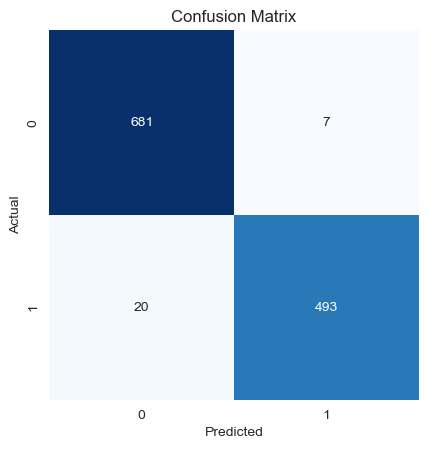

In [83]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [84]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность: {accuracy:.2f}")

Точность: 0.98


In [85]:
from sklearn.metrics import precision_score, recall_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Точность: {precision:.2f}")
print(f"Полнота: {recall:.2f}")

Точность: 0.99
Полнота: 0.96


In [86]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f"F1-мера: {f1:.2f}")

F1-мера: 0.97


In [87]:
df_copy.corr()

,budget,popularity,revenue,runtime,status,vote_average,vote_count,success,has_genres,has_director
budget,1.000000,0.505414,0.730823,0.269834,0.028640,0.093146,0.593180,0.546696,0.054375,0.055627
popularity,0.505414,1.000000,0.644724,0.225481,0.027023,0.273952,0.778130,0.456050,0.051329,0.053062
revenue,0.730823,0.644724,1.000000,0.251080,0.020608,0.197150,0.781487,0.549316,0.038655,0.040004
runtime,0.269834,0.225481,0.251080,1.000000,0.042465,0.373989,0.271927,0.232673,0.191341,0.174809
status,0.028640,0.027023,0.020608,0.042465,1.000000,0.023242,0.022664,0.034725,-0.003128,0.126374
vote_average,0.093146,0.273952,0.197150,0.373989,0.023242,1.000000,0.312997,0.202699,0.240818,0.179569
vote_count,0.593180,0.778130,0.781487,0.271927,0.022664,0.312997,1.000000,0.482659,0.042731,0.044178
success,0.546696,0.456050,0.549316,0.232673,0.034725,0.202699,0.482659,1.000000,0.065100,0.067399
has_genres,0.054375,0.051329,0.038655,0.191341,-0.003128,0.240818,0.042731,0.065100,1.000000,0.479909
has_director,0.055627,0.053062,0.040004,0.174809,0.126374,0.179569,0.044178,0.067399,0.479909,1.000000


#### Строим ROC-кривую

In [88]:
from sklearn.metrics import roc_curve, auc

# Получаем предсказанные вероятности для класса 1
y_score = model.predict_proba(X_test)[:, 1]

# Рассчитываем FPR, TPR и пороги
fpr, tpr, thresholds = roc_curve(y_test, y_score)

# Рассчитываем AUC (Area Under Curve) - площадь под кривой
roc_auc = auc(fpr, tpr)

#### Строим график

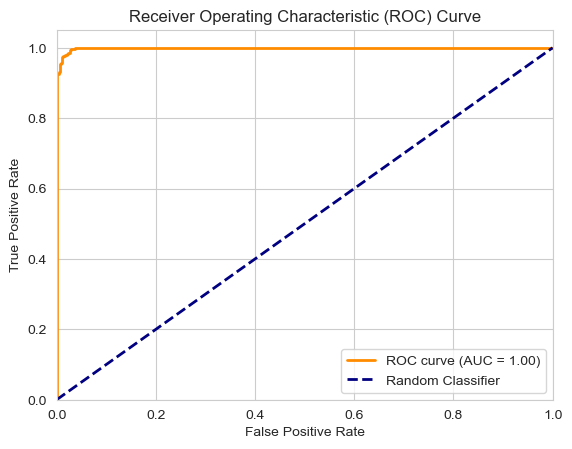

In [89]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### Преобразование категориальных признаков в числовые

In [92]:
print(df['status'].unique())

['Released' 'Post Production' 'Rumored']


In [93]:
from sklearn.preprocessing import LabelEncoder
labelencoder_status = LabelEncoder()
df_copy['status'] = labelencoder_status.fit_transform(df_copy['status'])

df_copy.iloc[:, [0, 1, 2, 3, 4, 5]]

,budget,popularity,revenue,runtime,status,vote_average
0,237000000,150.437577,2787965087,162.0,1,7.2
1,300000000,139.082615,961000000,169.0,1,6.9
2,245000000,107.376788,880674609,148.0,1,6.3
3,250000000,112.312950,1084939099,165.0,1,7.6
4,260000000,43.926995,284139100,132.0,1,6.1
...,...,...,...,...,...,...
4798,220000,14.269792,2040920,81.0,1,6.6
4799,9000,0.642552,0,85.0,1,5.9
4800,0,1.444476,0,120.0,1,7.0
4801,0,0.857008,0,98.0,1,5.7
